<div style="padding: 20px 0; text-align: center; font-weight: bold; font-size: 170%; background-color: #1d4055; color: #ffffff;"> Εργαστήριο 05. Προγραμματισμός - Τύποι δεδομένων (Λύσεις) </div>

# Αναδρομή σε συμβολοσειρά

Υλοποιήστε αναδρομική συνάρτηση Python, έστω  _getDigitSum_, η οποία επιστρέφει το άθροισμα των ψηφίων ενός αριθμού αφού πρώτα το έχει μετατρέψει σε συμβολοσειρά. Μία κατάλληλη κλήση για num=12345 θα ήταν getDigitSum(str(num)) που θα πρέπει να επιστρέψει 15.

In [3]:
def getDigitSum(s):
    if len(s) == 0:
        return 0
    return int(s[0]) + getDigitSum(s[1:])
num = 12345
getDigitSum(str(num))

15

# Σχήματα με *

Με την βοήθεια των τελεστών `+` και `*` σχεδιάστε με σύμβολα *:

1. Ένα διαμάντι (πυραμίδα και αντίστροφη πυραμίδα) για δεδομένο _height_.

2. Ένα κενό στη μέση πλαίσιο για δεδομενο _height_ και _width_.

In [4]:
# 1
height = 5
for i in range(height):
    print(" " * (height - i - 1) + "*" * (2 * i + 1))
for i in range(height - 2, -1, -1):
    print(" " * (height - i - 1) + "*" * (2 * i + 1))

    *
   ***
  *****
 *******
*********
 *******
  *****
   ***
    *


In [5]:
# 2
height=5
width=6
for i in range(height):
    if i == 0 or i == height - 1:
        print("*" * width)
    else:
        print("*" + " " * (width - 2) + "*")

******
*    *
*    *
*    *
******


# srange, Εγγεγραμμένα πολύγωνα

Δίνεται ο επόμενος κώδικας των σημειώσεων που δημιουργεί εγγεγραμμένα πολύγωνα _nsides_ πλευρών. Δημιουργήστε κατάλληλη συνάρτηση Python που θα δέχεται σαν παράμετρο τον αριθμό των πλευρών και καλέστε την κατάλληλα ώστε να δημιουργήσετε στο ίδιο γράφημα εγγεγραμμένα από τρίγωνο έως δεκάγωνο.

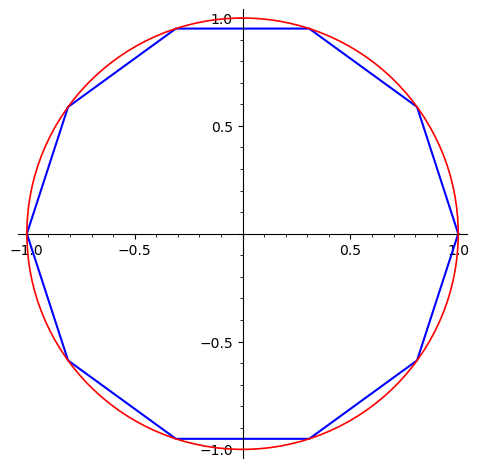

In [6]:
r = 1
nsides = 10
angles = srange(0, 2*pi, 2*pi/nsides)
mypoints = []
for angle in angles:
    xpoint = r * cos(angle)
    ypoint = r * sin(angle)
    mypoints.append((xpoint, ypoint))
mypoints.append(mypoints[0])
polygon_plot = list_plot(mypoints, plotjoined=True, color='blue', thickness=1.5)
circle_plot = circle((0, 0), r, color='red', thickness=1.2)
show(polygon_plot + circle_plot)

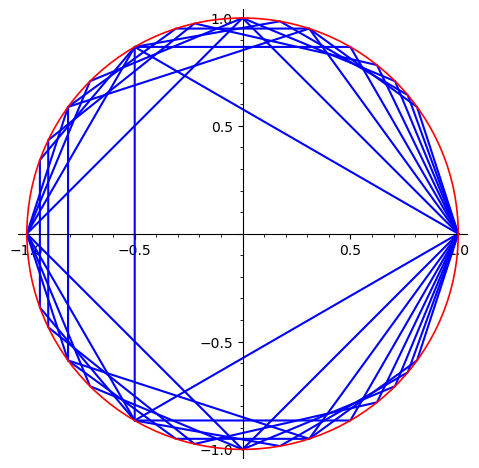

In [7]:
r = 1
def myPolygon(nsides):
    angles = srange(0, 2*pi, 2*pi/nsides)
    mypoints = []
    for angle in angles:
        xpoint = r * cos(angle)
        ypoint = r * sin(angle)
        mypoints.append((xpoint, ypoint))
    mypoints.append(mypoints[0])
    return list_plot(mypoints, plotjoined=True, color='blue', thickness=1.5)
g = Graphics()
for i in range(3,11):
    g+=myPolygon(i)
g +=circle((0, 0), r, color='red', thickness=1.2)
g.show()

# srange, κυματομορφή

Χρησιμοποιώντας `srange`, δημιουργήστε _npoints_ σημεία που να ακολουθούν τη συνάρτηση $f(x)=A⋅sin(k⋅x)$, όπου _A_ είναι το πλάτος και _k_ είναι ο ρυθμός συχνότητας. Στη συνέχεια, σχεδίασε τη γραφική παράσταση αυτών των σημείων. Τον αριθμό των σημείων, καθώς και τα _A_, _k_ θα τον θέτετε αρχικά εσείς. 

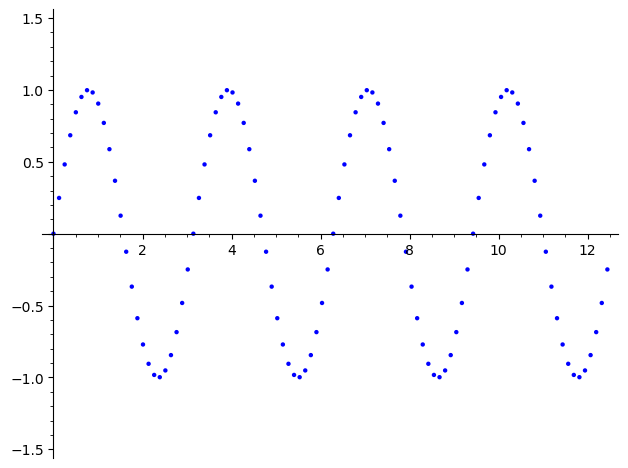

In [8]:
A = 1
k = 2
f(x)= A*sin(k*x)
npoints = 100
xpoints = srange(0, 4*pi, 4*pi/npoints)
points = []
for xpoint in xpoints:
    ypoint = f(xpoint)
    points.append((xpoint, ypoint))
list_plot(points, color='blue', ymin=-A-0.5, ymax=A+0.5)

# Σχεδιασμός λίστας γραφημάτων

Έστω μία λίστα με στοιχεία συναρτήσεων όπως το παράδειγμα που ακολουθεί. Με κατάλληλη χρήση δομής επανάληψης `for` και διαδοχικές `plot` σχεδιάστε σε ένα γράφημα τις παραστάσεις με το χρώμα και το `legend_label` που δίνεται.

In [1]:
functions = [
    (x^2, '$x^2$', 'blue'),
    (5-x^2, '$5-x^2(x)$', 'green'),
    (5*sin(x), '$5sin(x)$', 'red'),
    (exp(x)/10-2, '$\\frac{e^x}{10} - 2$', 'purple')
]

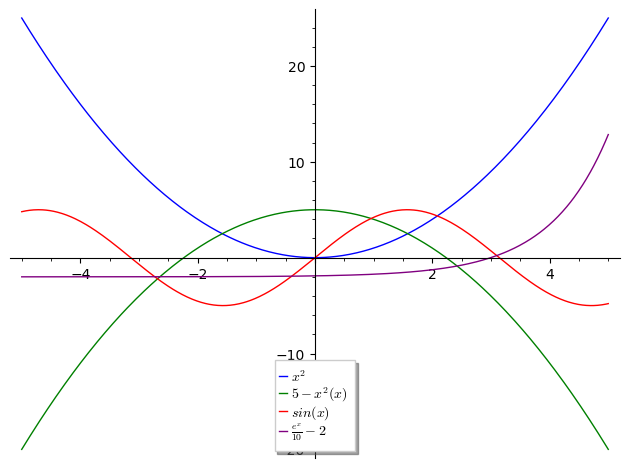

In [10]:
g = Graphics()

for f, label, color in functions:
    plot_function = plot(f, (x, -5, 5), color=color, legend_label=label)
    g += plot_function
g.show()

# Τυχαίος περίπατος

Κατά τη διάρκεια μιας τυχαίας πορείας, ένα σωματίδιο ξεκινά από την αρχή των αξόνων και κινείται μια σταθερή απόσταση _length_
κάθε χρονική στιγμή σε τυχαία κατεύθυνση προς τα αριστερά, δεξιά, πάνω ή κάτω, ανεξάρτητα από την προηγούμενη κίνησή του. Η τροχιά του αποτελεί μία λίστα που αρχικά περιέχει την αρχική του θέση. Στη τέλος, προσθέτουμε ένα κόκκινο σημείο που δείχνει την ευθεία πορεία από την αρχική έως την τελική του θέση. Δημιουργήστε και ένα πλέγμα με άλλο χρώμα λίγότερο έντονο πάνω στο οποίο θα φαίνεται η πορεία του σωματιδίου.
Σημείωση: Η `choice` μπορεί να χρησιμοποιηθεί για να επιλέξει τυχαία ένα στοιχείο από μία λίστα ή γενικότερα από μια συλλογή στοιχείων, π.χ. `theta = choice([0, pi/2, pi, 3*pi/2])` Εφόσον έχουμε την γωνια η επόμενη θέση του σωματιδίου μπορεί να είναι η `(xc + length*cos(theta),yc + length*sin(theta))`.

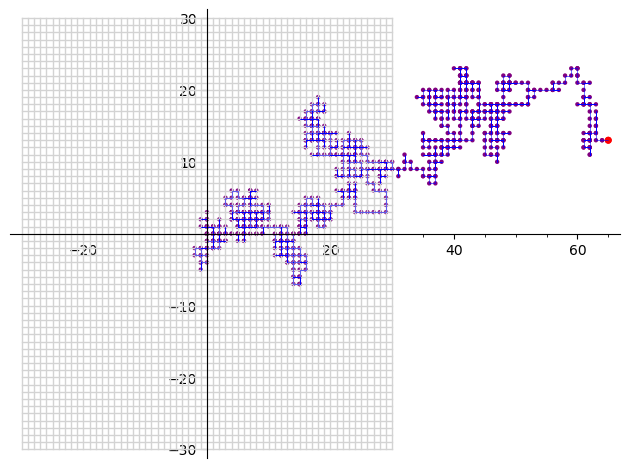

In [11]:
m = 1000 
length = 1
xc = 0
yc = 0
# Δημιουργία λίστας σημείων
p = [(0,0)]
for i in srange(m):
    theta = choice([0, pi/2, pi, 3*pi/2])
    xc = xc + length*cos(theta)
    yc = yc + length*sin(theta)
    p.append((xc, yc))
g = point(p[m], color = 'red', size = 25)

# Πλέγμα
size = 30
for i in range(-size,size + 1):
    g += line([(i, -size), (i, size)], color='lightgray')
for j in range(-size,size + 1):
    g += line([(-size, j), (size, j)], color='lightgray')
for (x, y) in p:
    g += point((x, y), color='purple', size=10)
g += line(p, thickness=0.4)
g += point(p[m], color='red', size=25)
g.show()

# Πλειάδες, σημεία

Το μέσο σημείο M μεταξύ δύο σημείων $A=(x_1,y_1)$ και $B=(x_2,y_2)$ δίνεται από τον τύπο:
$$
M = \left( \frac{x_1 + x_2}{2}, \frac{y_1 + y_2}{2}\right)
$$

1. Βρείτε το μέσο σημείο των Α=(1,3), Β=(5,7) και σχεδιάστε γράφημα με τα σημεία A, B, M και το ευθύγραμμο τμήμα A, B.

2. Σχεδιάστε γραφική παράσταση των σημείων A, B, M και του ευθύγραμμου τμήματος AB με την βοήθεια των point, line.

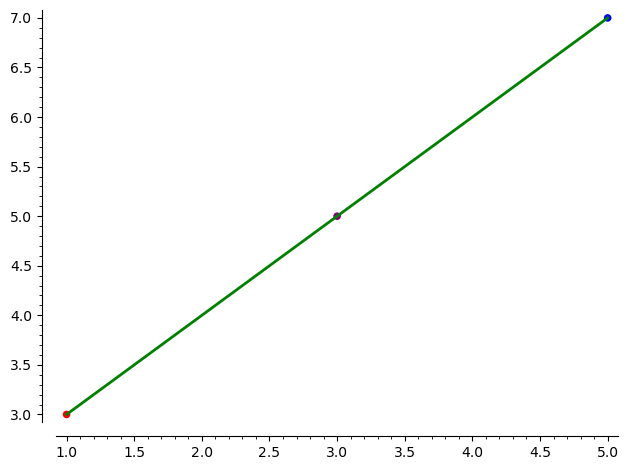

In [12]:
A = (1, 3)
B = (5, 7)

M = ((A[0] + B[0]) / 2, (A[1] + B[1]) / 2)

point_A = point(A, size=30, color='red')
point_B = point(B, size=30, color='blue')
point_M = point(M, size=30, color='purple')

line_AB = line([A, B], color='green', thickness=2)

point_A + point_B + point_M + line_AB

# Πλειάδες, απόσταση Manhattan 

Η απόσταση Manhattan (ή L1 απόσταση) μεταξύ δύο σημείων $A=(x_1,\dots, x_n)$, $B=(y_1,\dots, y_n)$ σε έναν n-διάστατο χώρο υπολογίζεται ως το άθροισμα των απόλυτων διαφορών των αντίστοιχων συντεταγμένων:
$$
d_{\text{Manhattan}}(A, B) = \sum_{i=1}^{n} |x_i - y_i|
$$

Υλοποιήστε τον τύπο για οποιαδήποτε διάσταση και εφαρμόστε τον για σημεία A=(1,2,3), B=(4,6,8)

In [13]:
A=(1,2,3)
B=(4,6,8)
s=0
for i in range(len(A)): s +=  abs(A[i] - B[i])
s

12

# Λεξικά, αριθμοί catalan

Οι αριθμοί catalan πήραν το όνομά τους από τον Βέλγο μαθηματικό Eugène Charles Catalan, ο οποίος μελέτησε τις ιδιότητές τους και έχουν διάφορες εφαρμογές. 
Ο τύπος για τον $n$-οστό αριθμό Catalan μπορεί να εκφραστεί ως εξής:
$$
C_n = \frac{1}{n + 1} \binom{2n}{n}
$$
ή ισοδύναμα με τη χρήση αθροίσματος:
$$
C_n = \sum_{i=0}^{n-1} C_i \cdot C_{n-i-1}
$$
όπου $C_0 = 1$ και $C_1 = 1$ οι αρχικές τιμές της ακολουθίας. 

Δημιουργήστε δύο εκδόσεις αναδρομικών συναρτήσεων python που θα υπολογίζουν τον m-στο αριθμό catalan.

- Χωρίς χρήση λεξικού με απλή αναδρομή.

- Εφαρμόστε τεχνική **memoization** με την βοήθεια λεξικού.

- Υπολογίστε τον χρόνο στις δύο εκδόσεις σας καθώς και στην `catalan_number` που δίνεται από το Sage για τον υπολογισμό του ίδιου αριθμού.

In [14]:
import time
# Ανδρομική έκδοση χωρίς memoization
def catalan(m):
    if m <= 1:
        return 1
    res = 0
    for i in range(m):
        res += catalan(i) * catalan(m-i-1)

    return res
# Ανδρομική έκδοση με memoization
catalan_dict = {}
def catalanmemo(m):
    if m in catalan_dict:
        return catalan_dict[m]
    if m <= 1:
        catalan_dict[m] = 1
        return 1
    res = 0
    for i in range(m):
        res += catalanmemo(i) * catalanmemo(m - i - 1)
    catalan_dict[m] = res
    return res
start_time = time.time()
print(catalan(15))
end_time = time.time()
print('time:',end_time-start_time)
start_time = time.time()
print(catalanmemo(15))
end_time = time.time()
print('time:',end_time-start_time)
start_time = time.time()
print(catalan_number(15))
end_time = time.time()
print('time:',end_time-start_time)

9694845
time: 15.911074876785278
9694845
time: 0.00021648406982421875
9694845
time: 0.00015926361083984375


# Solve, λεξικό

Δίνεται η συνάρτηση
$$
f(x) = x^2 - 4x + 3
$$
και η συνάρτηση
$$
g(x) = -x + 3
$$

1. Σχεδιάστε τις γραφικές παραστάσεις των δύο συναρτήσεων στο διάστημα  [-1, 5].

2. Καθορίστε τα σημεία τομής των συναρτήσεων και σχεδιάστε τα σημεία.

Σημείωση: Χρησιμοποιήστε λεξικό και την `solve`.

Σημείο τομής: (0, 3)
Σημείο τομής: (3, 0)


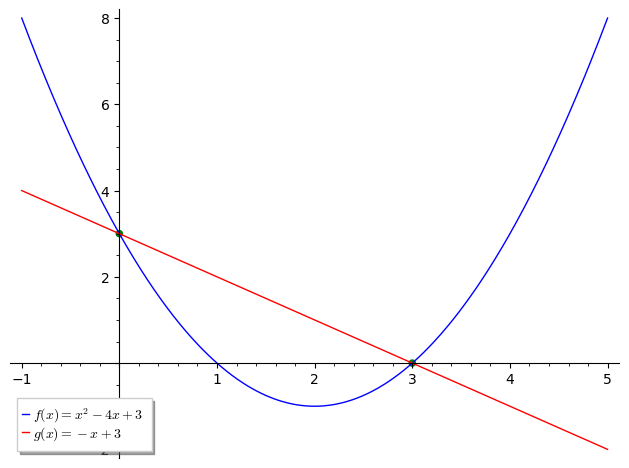

In [15]:
f(x) = x^2 - 4*x + 3 
g(x) = -x + 3

intersectionpoints = solve(f(x) == g(x), x, solution_dict=True)

# Δημιουργία γραφικών αντικειμένων
gr = plot(f(x), (x, -1, 5), color='blue', legend_label=r'$f(x) = x^2 - 4x + 3$')
gr += plot(g(x), (x, -1, 5), color='red', legend_label=r'$g(x) = -x + 3$')

for interpoint in intersectionpoints:
    x_value = interpoint[x]
    y_value = f(x_value)
    gr += point((x_value, y_value), color='green', size=30)
    print("Σημείο τομής:", (x_value, y_value))

gr.show()

# Comprehenion και list_plot

Δημιουργήστε με comprehension μία λίστα 100 σημείων με πεδίο ορισμού το [0,10] της συνάρτησης $y = e^{-0.1x} \cdot (\sin(x) + \cos(2x))$ και σχεδιάστε τα με την βοήθεια της `list_plot`.

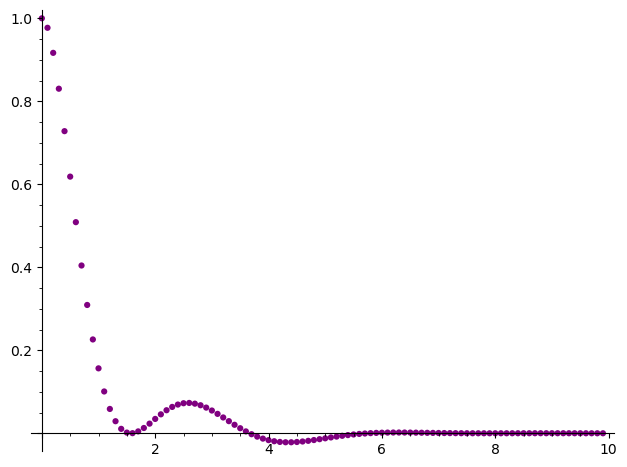

In [16]:
L = [(0.1*i, exp(-0.1*i) * (sin(0.1*i) + cos(2 * 0.1*i))) for i in range(100)]
list_plot(L, size=20, color='purple')

# Ολοκλήρωση με τον κανόνα του τραπεζίου

Ορίζουμε μία διαμέριση $Ρ_ν$ του [α, β] $α = x_0 < x_1 < x_2 < \cdots <x_ν = β$
Το **άθροισμα Riemann** $S(f, P_n)$ της συνάρτησης $f$ για τη διαμέριση $P_n$, με το ύψος σε κάθε υποδιάστημα να λαμβάνεται ως ο μέσος όρος της τιμής της συνάρτησης στα δύο άκρα του, ορίζεται ως:
$$
\sum_{k=1}^n \frac{f(x_{k-1}) + f(x_k)}{2} \cdot \Delta x_k =  \frac{f(x_0) + f(x_1)}{2} \cdot \Delta x_1 + \frac{f(x_1) + f(x_2)}{2} \cdot \Delta x_2 + \cdots + \frac{f(x_{n-1}) + f(x_n)}{2} \cdot \Delta x_n
$$

Χωρίζουμε το διάστημα $[0, \pi]$ σε $n$ ίσα υποδιαστήματα, καθένα με πλάτος $\Delta x$. Χρησιμοποιούμε τον **κανόνα του τραπεζίου**: υπολογίζουμε το εμβαδόν κάθε τραπεζίου στο υποδιάστημα, λαμβάνοντας ως ύψος το μέσο όρο των τιμών της συνάρτησης στα άκρα $x_{k-1}$ και $x_k$. Το εμβαδόν κάθε τραπεζίου είναι:
$$
\frac{f(x_{k-1}) + f(x_k)}{2} \cdot \Delta x
$$

Αθροίζουμε τα εμβαδά όλων των τραπεζίων για να προσεγγίσουμε το συνολικό εμβαδόν κάτω από την καμπύλη. Όσο μικρότερο το πλάτος $\Delta x = x_k - x_{k-1}$, τόσο πιο ακριβής η προσέγγιση του εμβαδού, άρα και του ολοκληρώματος.

Θα σχεδιάσουμε επίσης τη γραφική παράσταση της συνάρτησης, μαζί με τα τραπέζια που σχηματίζουν την προσέγγιση του εμβαδού.


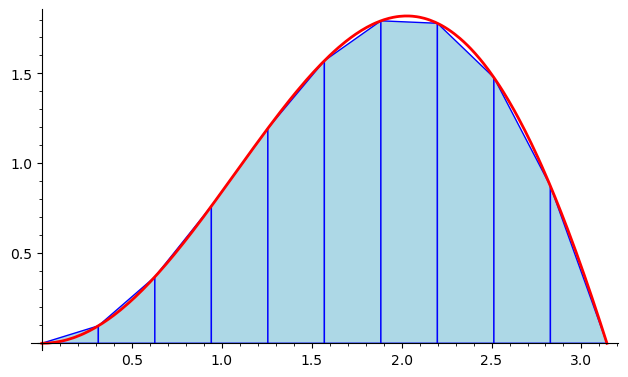

(3.11571148683107, 3.14159265358979)

In [17]:
f(x) = x * sin(x)
a, b = 0, pi
num = 10
dx = (b - a) / num
area = sum([n((f(a + i * dx) + f(a + (i - 1) * dx)) / 2 * dx) for i in range(1, num + 1)])

g = Graphics()
for i in range(1, num + 1):
    x_left = a + (i - 1) * dx
    x_right = a + i * dx
    height_left = f(x_left)
    height_right = f(x_right)
    g +=polygon([(x_left, 0), (x_left, height_left), (x_right, height_right), (x_right, 0)], color="lightblue", edgecolor="blue")
g+=plot(f, (x, a, b), color="red", thickness=2)
g.show()

area, n(integral(f, x, a, b))